## Imports

In [52]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sqlalchemy import create_engine

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

## Postgres Connection

In [53]:
import pandas as pd
import sqlalchemy
import psycopg2

print("pandas:", pd.__version__)
print("sqlalchemy:", sqlalchemy.__version__)
print("psycopg2:", psycopg2.__version__)

pandas: 2.3.2
sqlalchemy: 2.0.48
psycopg2: 2.9.11 (dt dec pq3 ext lo64)


In [54]:
import pandas as pd
from sqlalchemy import create_engine, text

DB_HOST = "localhost"
DB_NAME = "eventsdb"
DB_USER = "app"
DB_PASSWORD = "app123"
DB_PORT = "5432"

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

query = text("""
SELECT *
FROM gold_features_player_day
ORDER BY date, player_id
""")

with engine.connect() as conn:
    df = pd.read_sql_query(query, conn)

print(df.shape)
df.head()

(3709, 14)


,player_id,date,sessions_cnt,session_minutes,matches_played,wins,losses,early_exits,xp_earned,gold_earned,purchases_cnt,total_spent,level_gains,churn_7d
0,p_00001,2026-01-01,1,43617.116667,4,1,3,0,543,253,0,0.0,3,0
1,p_00002,2026-01-01,1,43617.133333,4,0,4,1,300,371,0,0.0,2,0
2,p_00003,2026-01-01,1,43617.066667,3,2,1,0,275,145,0,0.0,2,0
3,p_00004,2026-01-01,1,43617.033333,1,0,1,0,33,33,0,0.0,0,0
4,p_00005,2026-01-01,1,43616.983333,2,1,1,0,316,254,0,0.0,2,0


## First look in the data

In [55]:
print(df.info())
print("\nNulls per column:\n")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df["churn_7d"].value_counts(dropna=False))
print(df["churn_7d"].value_counts(normalize=True, dropna=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3709 entries, 0 to 3708
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   player_id        3709 non-null   object 
 1   date             3709 non-null   object 
 2   sessions_cnt     3709 non-null   int64  
 3   session_minutes  3709 non-null   float64
 4   matches_played   3709 non-null   int64  
 5   wins             3709 non-null   int64  
 6   losses           3709 non-null   int64  
 7   early_exits      3709 non-null   int64  
 8   xp_earned        3709 non-null   int64  
 9   gold_earned      3709 non-null   int64  
 10  purchases_cnt    3709 non-null   int64  
 11  total_spent      3709 non-null   float64
 12  level_gains      3709 non-null   int64  
 13  churn_7d         3709 non-null   int64  
dtypes: float64(2), int64(10), object(2)
memory usage: 405.8+ KB
None

Nulls per column:

player_id          0
date               0
sessions_cnt       0
sess

## Sanity Checks

In [56]:
display(df.describe(include="all"))

,player_id,date,sessions_cnt,session_minutes,matches_played,wins,losses,early_exits,xp_earned,gold_earned,purchases_cnt,total_spent,level_gains,churn_7d
count,3709,3709,3709.000000,3709.000000,3709.000000,3709.000000,3709.000000,3709.000000,3709.000000,3709.000000,3709.000000,3709.000000,3709.000000,3709.000000
unique,126,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,p_00001,2026-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,30,126,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,0.033702,1140.639831,3.951739,1.976004,1.975735,0.315179,393.504988,258.775950,0.471556,53.668105,0.271771,0.019682
std,NaN,NaN,0.180485,6961.375987,1.891926,1.375630,1.360942,0.562817,210.685491,172.360536,0.672356,117.295428,0.632211,0.138923
min,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,0.000000,0.000000,3.000000,1.000000,1.000000,0.000000,238.000000,132.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,NaN,0.000000,0.000000,4.000000,2.000000,2.000000,0.000000,367.000000,239.000000,0.000000,0.000000,0.000000,0.000000
75%,NaN,NaN,0.000000,0.000000,5.000000,3.000000,3.000000,1.000000,522.000000,363.000000,1.000000,40.000000,0.000000,0.000000


In [57]:
dup_count = df.duplicated(subset=["player_id", "date"]).sum()
print(f"Duplicate (player_id, date) rows: {dup_count}")

Duplicate (player_id, date) rows: 0


In [58]:
if dup_count > 0:
    df = df.drop_duplicates(subset=["player_id", "date"])
    print("Duplicates removed.")
    print(df.shape)

## Data Preperation

In [59]:
target_col = "churn_7d"

feature_cols = [
    "sessions_cnt",
    "session_minutes",
    "matches_played",
    "wins",
    "losses",
    "early_exits",
    "xp_earned",
    "gold_earned",
    "purchases_cnt",
    "total_spent",
    "level_gains"
]

X = df[feature_cols].copy()
y = df[target_col].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3709, 11)
y shape: (3709,)


In [60]:
print("Unique target values:", sorted(y.dropna().unique()))

Unique target values: [0, 1]


In [61]:
y = y.astype(int)

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain target ratio:")
print(y_train.value_counts(normalize=True))
print("\nTest target ratio:")
print(y_test.value_counts(normalize=True))

Train shape: (2967, 11)
Test shape: (742, 11)

Train target ratio:
churn_7d
0    0.980452
1    0.019548
Name: proportion, dtype: float64

Test target ratio:
churn_7d
0    0.979784
1    0.020216
Name: proportion, dtype: float64


In [63]:
baseline_pred = np.zeros_like(y_test)

print("Baseline Accuracy:", accuracy_score(y_test, baseline_pred))
print("Baseline Precision:", precision_score(y_test, baseline_pred, zero_division=0))
print("Baseline Recall:", recall_score(y_test, baseline_pred, zero_division=0))
print("Baseline F1:", f1_score(y_test, baseline_pred, zero_division=0))

Baseline Accuracy: 0.9797843665768194
Baseline Precision: 0.0
Baseline Recall: 0.0
Baseline F1: 0.0


## Logistic Regression

In [64]:
logreg_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight="balanced"
    ))
])

logreg_pipeline.fit(X_train, y_train)

logreg_pred = logreg_pipeline.predict(X_test)
logreg_proba = logreg_pipeline.predict_proba(X_test)[:, 1]

## Evaluation

In [65]:
def evaluate_model(model_name, y_true, y_pred, y_proba):
    print(f"--- {model_name} ---")
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred, zero_division=0), 4))
    print("Recall   :", round(recall_score(y_true, y_pred, zero_division=0), 4))
    print("F1       :", round(f1_score(y_true, y_pred, zero_division=0), 4))
    print("ROC-AUC  :", round(roc_auc_score(y_true, y_proba), 4))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

In [66]:
evaluate_model("Logistic Regression", y_test, logreg_pred, logreg_proba)

--- Logistic Regression ---
Accuracy : 0.5445
Precision: 0.0346
Recall   : 0.8
F1       : 0.0663
ROC-AUC  : 0.6966

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.54      0.70       727
           1       0.03      0.80      0.07        15

    accuracy                           0.54       742
   macro avg       0.51      0.67      0.38       742
weighted avg       0.97      0.54      0.69       742


Confusion Matrix:
[[392 335]
 [  3  12]]


## ROC Curve

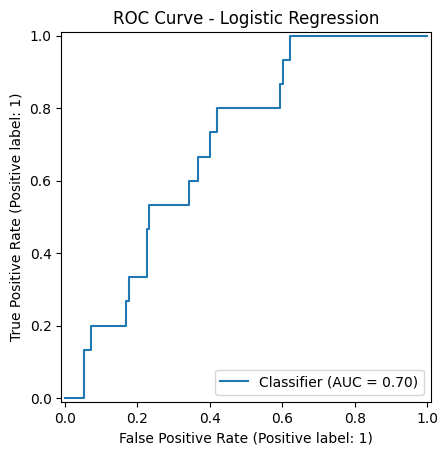

In [67]:
RocCurveDisplay.from_predictions(y_test, logreg_proba)
plt.title("ROC Curve - Logistic Regression")
plt.show()

In [68]:
logreg_model = logreg_pipeline.named_steps["model"]

coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": logreg_model.coef_[0]
}).sort_values("coefficient", ascending=False)

coef_df

,feature,coefficient
1,session_minutes,0.705045
8,purchases_cnt,0.147717
7,gold_earned,0.133104
10,level_gains,0.025031
4,losses,-0.084077
5,early_exits,-0.102715
9,total_spent,-0.133095
3,wins,-0.146195
2,matches_played,-0.167069
6,xp_earned,-0.245656


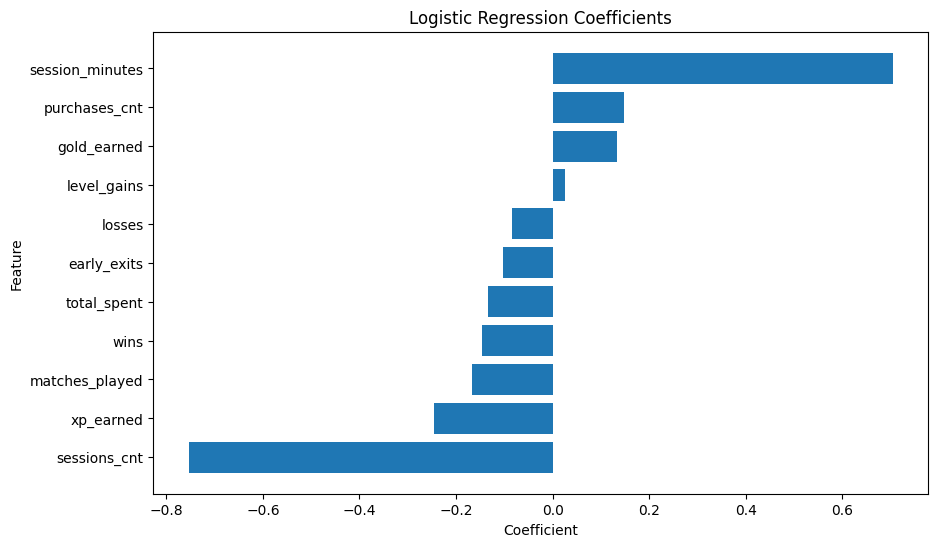

In [69]:
plt.figure(figsize=(10, 6))
plt.barh(coef_df["feature"], coef_df["coefficient"])
plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

## Random Forest

In [70]:
rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)
rf_proba = rf_pipeline.predict_proba(X_test)[:, 1]

## Random Forest Evaluation

In [71]:
evaluate_model("Random Forest", y_test, rf_pred, rf_proba)

--- Random Forest ---
Accuracy : 0.9488
Precision: 0.04
Recall   : 0.0667
F1       : 0.05
ROC-AUC  : 0.6273

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       727
           1       0.04      0.07      0.05        15

    accuracy                           0.95       742
   macro avg       0.51      0.52      0.51       742
weighted avg       0.96      0.95      0.96       742


Confusion Matrix:
[[703  24]
 [ 14   1]]


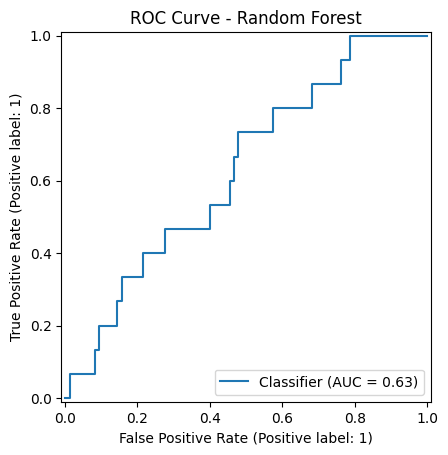

In [72]:
RocCurveDisplay.from_predictions(y_test, rf_proba)
plt.title("ROC Curve - Random Forest")
plt.show()

## Feature Importance

In [73]:
rf_model = rf_pipeline.named_steps["model"]

rf_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

rf_importance_df

,feature,importance
6,xp_earned,0.291442
7,gold_earned,0.235030
2,matches_played,0.102290
9,total_spent,0.085879
3,wins,0.078918
4,losses,0.074833
5,early_exits,0.045681
8,purchases_cnt,0.037212
10,level_gains,0.033420
1,session_minutes,0.010594


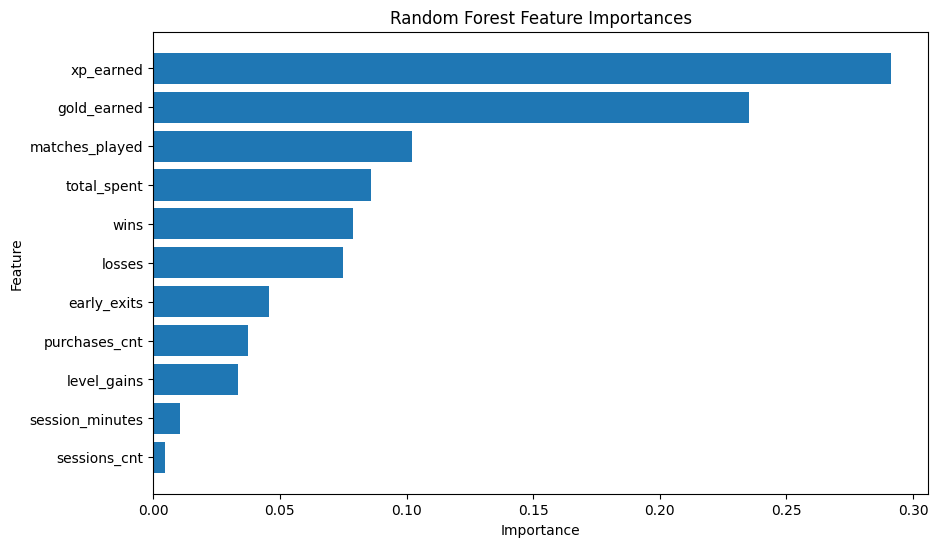

In [74]:
plt.figure(figsize=(10, 6))
plt.barh(rf_importance_df["feature"], rf_importance_df["importance"])
plt.title("Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

## MOdels results

In [75]:
results = []

def collect_metrics(model_name, y_true, y_pred, y_proba):
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba)
    }

results.append(collect_metrics("Logistic Regression", y_test, logreg_pred, logreg_proba))
results.append(collect_metrics("Random Forest", y_test, rf_pred, rf_proba))

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
results_df

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.544474,0.034582,0.800000,0.066298,0.696561
1,Random Forest,0.948787,0.040000,0.066667,0.050000,0.627327


<Figure size 800x400 with 0 Axes>

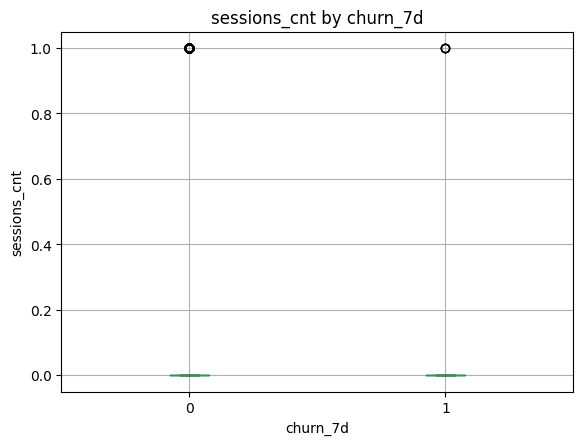

<Figure size 800x400 with 0 Axes>

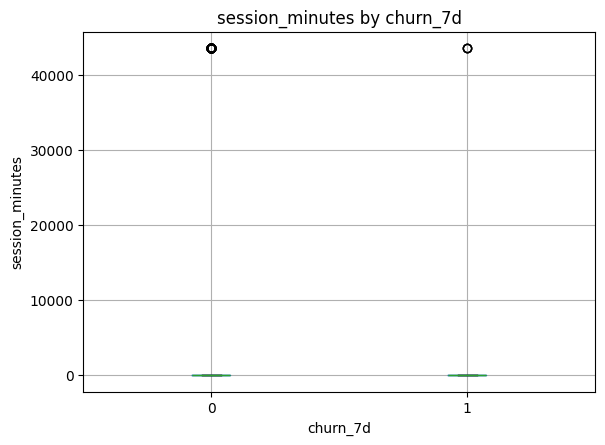

<Figure size 800x400 with 0 Axes>

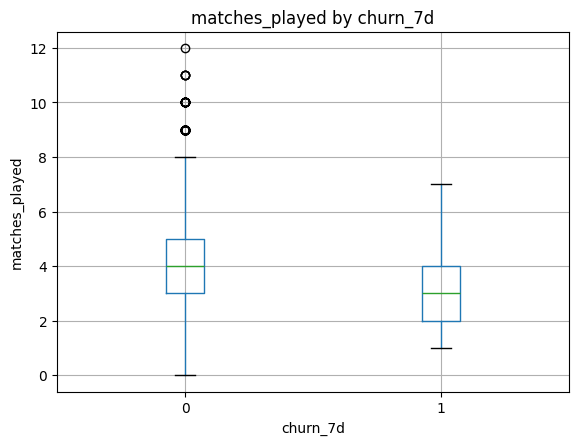

<Figure size 800x400 with 0 Axes>

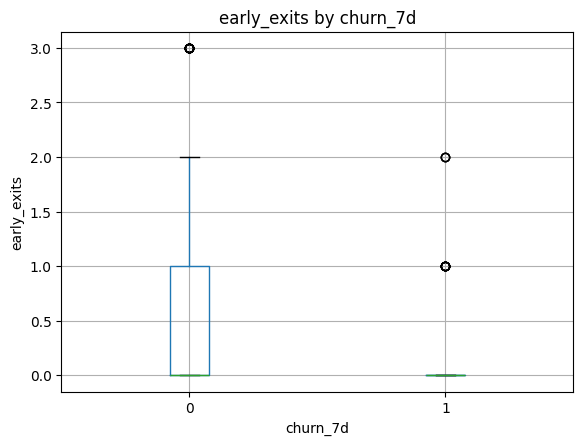

<Figure size 800x400 with 0 Axes>

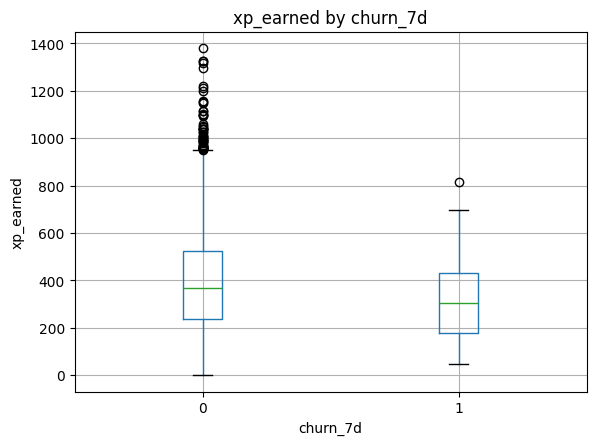

<Figure size 800x400 with 0 Axes>

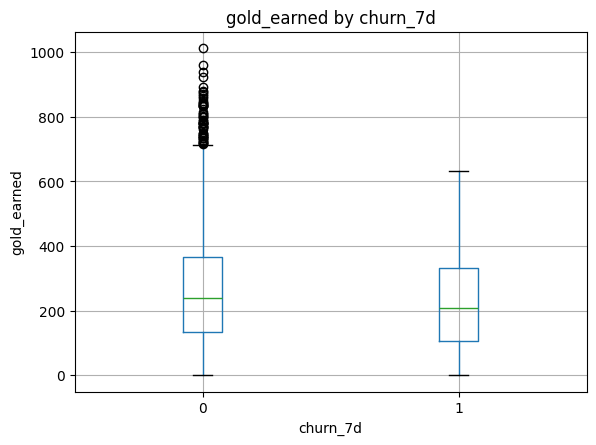

<Figure size 800x400 with 0 Axes>

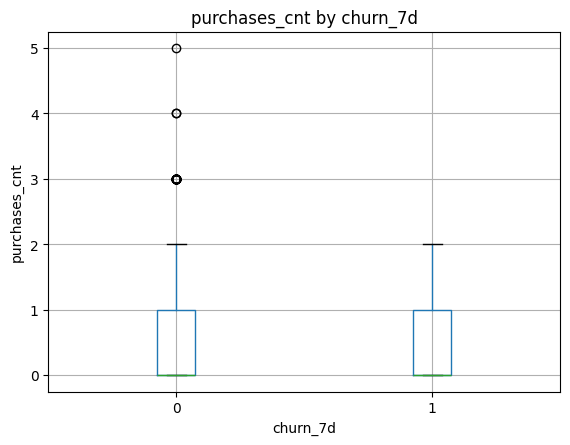

<Figure size 800x400 with 0 Axes>

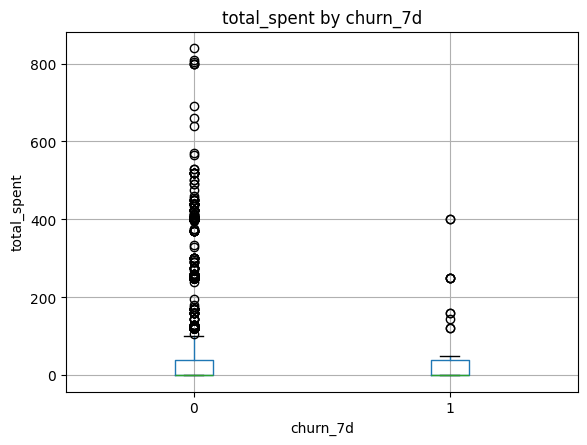

<Figure size 800x400 with 0 Axes>

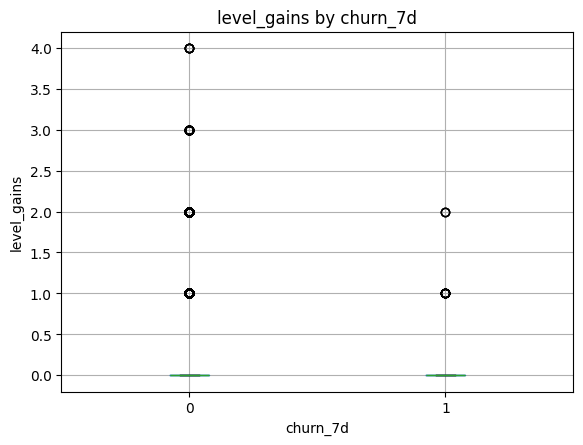

In [76]:
cols_to_plot = [
    "sessions_cnt",
    "session_minutes",
    "matches_played",
    "early_exits",
    "xp_earned",
    "gold_earned",
    "purchases_cnt",
    "total_spent",
    "level_gains"
]

for col in cols_to_plot:
    plt.figure(figsize=(8, 4))
    df.boxplot(column=col, by="churn_7d")
    plt.title(f"{col} by churn_7d")
    plt.suptitle("")
    plt.xlabel("churn_7d")
    plt.ylabel(col)
    plt.show()

Automatic Understandings

In [77]:
top_rf = rf_importance_df.head(5)["feature"].tolist()
top_lr_pos = coef_df.head(5)["feature"].tolist()
top_lr_neg = coef_df.tail(5)["feature"].tolist()

print("Top Random Forest features:", top_rf)
print("Top positive Logistic features (increase churn):", top_lr_pos)
print("Top negative Logistic features (reduce churn):", top_lr_neg)

Top Random Forest features: ['xp_earned', 'gold_earned', 'matches_played', 'total_spent', 'wins']
Top positive Logistic features (increase churn): ['session_minutes', 'purchases_cnt', 'gold_earned', 'level_gains', 'losses']
Top negative Logistic features (reduce churn): ['total_spent', 'wins', 'matches_played', 'xp_earned', 'sessions_cnt']
